### Module Import

In [1]:
# https://github.com/HideOnHouse/TorchBase

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from dataset import MyDataset
from model import get_Model
from learning import train, evaluate, calc_acc
from inference import inference

### 함수 선언

In [2]:
def label2int(data, label_tags):
    for i in range(len(data)):
        data.iloc[i,1] = label_tags.index(data.iloc[i, 1])
    return data


def draw_history(history):
    train_loss = history["train_loss"]
    train_acc = history["train_acc"]
    valid_loss = history["valid_loss"]
    valid_acc = history["valid_acc"]

    plt.subplot(2,1,1)
    plt.plot(train_loss, label="train")
    plt.plot(valid_loss, label="valid")
    plt.legend()

    plt.subplot(2,1,2)
    plt.plot(train_acc, label="train")
    plt.plot(valid_acc, label="valid")
    plt.legend()

    plt.show()

In [3]:
# label_tags
label_tags = ['불안', '슬픔', '상처', '당황', '분노', '기쁨']

train_path = "train.csv"
test_path = "test.csv"

train_data = pd.read_csv(train_path, encoding='cp949')
test_data = pd.read_csv(test_path, encoding='cp949')

train_data = label2int(train_data, label_tags)
test_data = label2int(test_data, label_tags)

# your Data Pre-Processing
train_x, train_y = train_data.iloc[:, :1], train_data.iloc[:, 1:]
test_x, test_y = test_data.iloc[:, :1], test_data.iloc[:, 1:]

# data split
train_x, valid_x, train_y, valid_y = train_test_split(train_x, train_y, stratify=train_y, random_state=17, test_size=0.05)

# Check Train, Valid, Test Image's Shape
print("The Shape of Train Input: ", train_x.shape)
print("The Shape of Valid Input: ", valid_x.shape)
print("The Shape of Test Input: ", test_x.shape)

# Check Train, Valid Label's Shape
print("The Shape of Train Labels: ", train_y.shape)
print("The Shape of Valid Labels: ", valid_y.shape)
print("The Shape of Valid Labels: ", test_y.shape)

# Create Dataset and DataLoader
train_dataset = MyDataset(train_x, train_y)
valid_dataset = MyDataset(valid_x, valid_y)
test_dataset = MyDataset(test_x, test_y)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

The Shape of Train Input:  (9405, 1)
The Shape of Valid Input:  (495, 1)
The Shape of Test Input:  (100, 1)
The Shape of Train Labels:  (9405, 1)
The Shape of Valid Labels:  (495, 1)
The Shape of Valid Labels:  (100, 1)


In [4]:
model_name = "MyModel_1"
model = get_Model(model_name)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

print(device)

Some weights of the model checkpoint at kykim/bert-kor-base were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


cuda


In [5]:
# train
print("============================= Train =============================")
history = train(model, device, optimizer, criterion, 10, train_loader, valid_loader)

============================= Train =============================
294it [01:54,  2.56it/s, epoch=1/10, loss=1.277157, acc=0.515]
16it [00:02,  7.24it/s, loss=1.236697, acc=0.646]
294it [01:52,  2.62it/s, epoch=2/10, loss=1.197730, acc=0.671]
16it [00:02,  6.14it/s, loss=1.294564, acc=0.626]
294it [01:52,  2.62it/s, epoch=3/10, loss=0.386886, acc=0.740]
16it [00:02,  6.16it/s, loss=1.126242, acc=0.661]
294it [01:55,  2.55it/s, epoch=4/10, loss=0.729249, acc=0.807]
16it [00:02,  7.72it/s, loss=1.267233, acc=0.648]
294it [01:52,  2.62it/s, epoch=5/10, loss=0.488714, acc=0.856]
16it [00:02,  7.79it/s, loss=1.690231, acc=0.628]
294it [01:52,  2.61it/s, epoch=6/10, loss=0.346631, acc=0.898]
16it [00:02,  7.36it/s, loss=1.820285, acc=0.634]
294it [01:51,  2.64it/s, epoch=7/10, loss=0.154160, acc=0.919]
16it [00:03,  4.82it/s, loss=1.755727, acc=0.638]
294it [01:55,  2.54it/s, epoch=8/10, loss=0.036553, acc=0.946]
16it [00:02,  7.71it/s, loss=2.213188, acc=0.640]
294it [01:51,  2.64it/s, epoch

In [7]:
# Test
print("============================= Test =============================")
test_loss, test_acc = evaluate(model, device, criterion, test_loader)
print("test loss : {:.6f}".format(test_loss))
print("test acc : {:.3f}".format(test_acc))

============================= Test =============================
4it [00:03,  1.13it/s, loss=0.223947, acc=0.610]
test loss : 1.293132
test acc : 0.610


In [8]:
file_name = model_name
torch.save(model, f"models/{file_name}.pt")
with open(f"models/{file_name}_history.pickle", 'wb') as f:
    pickle.dump(history, f, pickle.HIGHEST_PROTOCOL)

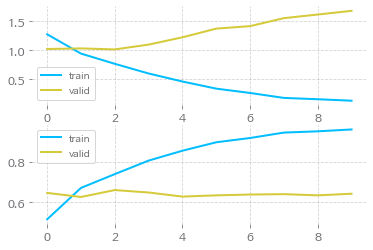

In [9]:
draw_history(history)